In [2]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import shap

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [4]:
MIMIC_PATH = Path("/Users/aaradhyaacharya/Documents/semesters/grad/sem4/30-Day Readmission Risk Analysis/mimic-iv/hosp")

con = duckdb.connect()

con.execute(f"CREATE VIEW admissions AS SELECT * FROM read_csv_auto('{MIMIC_PATH}/admissions.csv.gz')")
con.execute(f"CREATE VIEW patients AS SELECT * FROM read_csv_auto('{MIMIC_PATH}/patients.csv.gz')")
con.execute(f"CREATE VIEW diagnoses_icd AS SELECT * FROM read_csv_auto('{MIMIC_PATH}/diagnoses_icd.csv.gz')")
con.execute(f"CREATE VIEW labevents AS SELECT * FROM read_csv_auto('{MIMIC_PATH}/labevents.csv.gz')")

print("Connected to MIMIC-IV")

Connected to MIMIC-IV


In [5]:
cohort = con.execute("""
    WITH age_calc AS (
        SELECT 
            a.subject_id, a.hadm_id, a.admittime, a.dischtime,
            a.admission_type, a.discharge_location,
            a.insurance, a.marital_status, a.race,
            a.hospital_expire_flag,
            p.gender, p.anchor_age
        FROM admissions a
        JOIN patients p ON a.subject_id = p.subject_id
        WHERE p.anchor_age >= 18
          AND a.hospital_expire_flag = 0
          AND a.dischtime IS NOT NULL
          AND a.admission_type NOT IN ('ELECTIVE', 'NEWBORN')
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY subject_id ORDER BY admittime) AS rn
        FROM age_calc
    ),
    index_admissions AS (SELECT * FROM ranked WHERE rn = 1),
    readmissions AS (
        SELECT a.subject_id, a.admittime AS readmit_time
        FROM admissions a
        JOIN index_admissions i ON a.subject_id = i.subject_id
        WHERE a.hadm_id != i.hadm_id
          AND a.admittime > i.dischtime
          AND a.admittime <= i.dischtime + INTERVAL 30 DAYS
    )
    SELECT 
        i.*,
        CASE WHEN r.subject_id IS NOT NULL THEN 1 ELSE 0 END AS readmitted_30d,
        DATEDIFF('day', i.admittime, i.dischtime) AS los
    FROM index_admissions i
    LEFT JOIN readmissions r ON i.subject_id = r.subject_id
    WHERE DATEDIFF('day', i.admittime, i.dischtime) >= 0
""").df()

print(f"Cohort: {len(cohort):,} admissions, {cohort.readmitted_30d.mean():.1%} readmission rate")

Cohort: 220,836 admissions, 15.1% readmission rate


In [6]:
prior_util = con.execute("""
    WITH index_admits AS (
        SELECT a.subject_id, a.hadm_id, a.admittime AS index_time
        FROM admissions a
        JOIN (
            SELECT subject_id, MIN(admittime) AS first_admit
            FROM admissions
            WHERE admission_type NOT IN ('ELECTIVE', 'NEWBORN')
            GROUP BY subject_id
        ) f ON a.subject_id = f.subject_id AND a.admittime = f.first_admit
    )
    SELECT 
        i.hadm_id,
        COUNT(CASE WHEN a.admittime >= i.index_time - INTERVAL 6 MONTHS
                    AND a.admittime < i.index_time THEN 1 END) AS prior_admits_6m,
        COUNT(CASE WHEN a.admittime >= i.index_time - INTERVAL 12 MONTHS
                    AND a.admittime < i.index_time THEN 1 END) AS prior_admits_12m
    FROM index_admits i
    LEFT JOIN admissions a ON i.subject_id = a.subject_id
    GROUP BY i.hadm_id
""").df()

comorbidity = con.execute("""
    SELECT
        hadm_id,
        COUNT(*) AS n_icd_codes,
        MAX(CASE WHEN icd_version = 10 AND (
            icd_code LIKE 'I50%' OR icd_code LIKE 'J44%' OR icd_code LIKE 'N18%'
            OR icd_code LIKE 'C%' OR icd_code LIKE 'E11%' OR icd_code LIKE 'E10%'
            OR icd_code LIKE 'F20%' OR icd_code LIKE 'F31%'
            OR icd_code LIKE 'F32%' OR icd_code LIKE 'F33%'
        ) THEN 1 ELSE 0 END) AS high_risk_comorbidity
    FROM diagnoses_icd
    GROUP BY hadm_id
""").df()

cohort = cohort.merge(prior_util, on='hadm_id', how='left')
cohort = cohort.merge(comorbidity, on='hadm_id', how='left')
cohort[['prior_admits_6m','prior_admits_12m','n_icd_codes','high_risk_comorbidity']] = \
    cohort[['prior_admits_6m','prior_admits_12m','n_icd_codes','high_risk_comorbidity']].fillna(0)

print("Prior utilization and comorbidity features added")

Prior utilization and comorbidity features added


In [7]:
# Key lab item IDs in MIMIC-IV
LAB_ITEMS = {
    50912: 'creatinine',
    51006: 'bun', 
    50983: 'sodium',
    51222: 'hemoglobin',
    51301: 'wbc',
    50931: 'glucose',
    50862: 'albumin',
    50882: 'bicarbonate'
}

item_ids = ', '.join(str(k) for k in LAB_ITEMS.keys())
hadm_ids = ', '.join(str(h) for h in cohort['hadm_id'].tolist())

labs_raw = con.execute(f"""
    SELECT hadm_id, itemid, valuenum
    FROM (
        SELECT hadm_id, itemid, valuenum,
               ROW_NUMBER() OVER (
                   PARTITION BY hadm_id, itemid 
                   ORDER BY charttime DESC
               ) AS rn
        FROM labevents
        WHERE itemid IN ({item_ids})
          AND hadm_id IN ({hadm_ids})
          AND valuenum IS NOT NULL
          AND valuenum > 0
    ) sub
    WHERE rn = 1
""").df()

# Pivot to wide format
labs_wide = labs_raw.pivot_table(
    index='hadm_id', columns='itemid', values='valuenum'
).reset_index()
labs_wide.columns = ['hadm_id'] + [LAB_ITEMS[c] for c in labs_wide.columns[1:]]

# Add abnormal flags
labs_wide['creatinine_high'] = (labs_wide.get('creatinine', 0) > 1.5).astype(int)
labs_wide['hemoglobin_low']  = (labs_wide.get('hemoglobin', 99) < 10).astype(int)
labs_wide['wbc_high']        = (labs_wide.get('wbc', 0) > 12).astype(int)
labs_wide['sodium_low']      = (labs_wide.get('sodium', 99) < 135).astype(int)

cohort = cohort.merge(labs_wide, on='hadm_id', how='left')
print(f"Lab features added — coverage: {labs_wide.shape[0]/len(cohort):.1%} of admissions")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Lab features added — coverage: 74.3% of admissions


In [8]:
# Collapse race
def collapse_race(r):
    r = str(r).upper()
    if 'WHITE' in r: return 'White'
    if 'BLACK' in r: return 'Black'
    if 'HISPANIC' in r: return 'Hispanic'
    if 'ASIAN' in r: return 'Asian'
    if r in ['UNKNOWN','UNABLE TO OBTAIN','PATIENT DECLINED TO ANSWER']: return 'Unknown'
    return 'Other'

cohort['race_collapsed'] = cohort['race'].apply(collapse_race)

# Disease category
def disease_cat(row):
    # Uses primary ICD from diagnoses_icd — simplify with admission type proxy for now
    return 'Other'  # will be joined below

primary_dx = con.execute("""
    SELECT hadm_id, icd_code, icd_version
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY hadm_id ORDER BY seq_num) AS rn
        FROM diagnoses_icd WHERE seq_num = 1
    ) s WHERE rn = 1
""").df()

def map_disease(row):
    if row['icd_version'] != 10: return 'Other'
    c = str(row['icd_code'])[:3]
    if 'I00' <= c <= 'I99': return 'Circulatory'
    if 'J00' <= c <= 'J99': return 'Respiratory'
    if 'K00' <= c <= 'K99': return 'Digestive'
    if 'F00' <= c <= 'F99': return 'Mental/Behavioral'
    if 'C00' <= c <= 'D49': return 'Neoplasms'
    if 'E00' <= c <= 'E89': return 'Endocrine/Metabolic'
    if 'N00' <= c <= 'N99': return 'Genitourinary'
    if 'S00' <= c <= 'T98': return 'Injury/Poisoning'
    return 'Other'

primary_dx['disease_category'] = primary_dx.apply(map_disease, axis=1)
cohort = cohort.merge(primary_dx[['hadm_id','disease_category']], on='hadm_id', how='left')
cohort['disease_category'] = cohort['disease_category'].fillna('Other')

# Select features
cat_cols = ['gender', 'insurance', 'race_collapsed', 'admission_type', 
            'disease_category', 'high_risk_comorbidity']
num_cols = ['anchor_age', 'los', 'prior_admits_6m', 'n_icd_codes',
            'creatinine', 'bun', 'hemoglobin', 'wbc', 'sodium', 'albumin',
            'creatinine_high', 'hemoglobin_low', 'wbc_high', 'sodium_low']

df = cohort[cat_cols + num_cols + ['readmitted_30d']].copy()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df = df.fillna(df.median(numeric_only=True))

X = df.drop('readmitted_30d', axis=1)
y = df['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {X.shape[1]}")

Train: 176,668 | Test: 44,168 | Features: 40


In [9]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    random_state=42, eval_metric='auc', verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"XGBoost AUC:             {xgb_auc:.3f}")

Logistic Regression AUC: 0.644
XGBoost AUC:             0.679


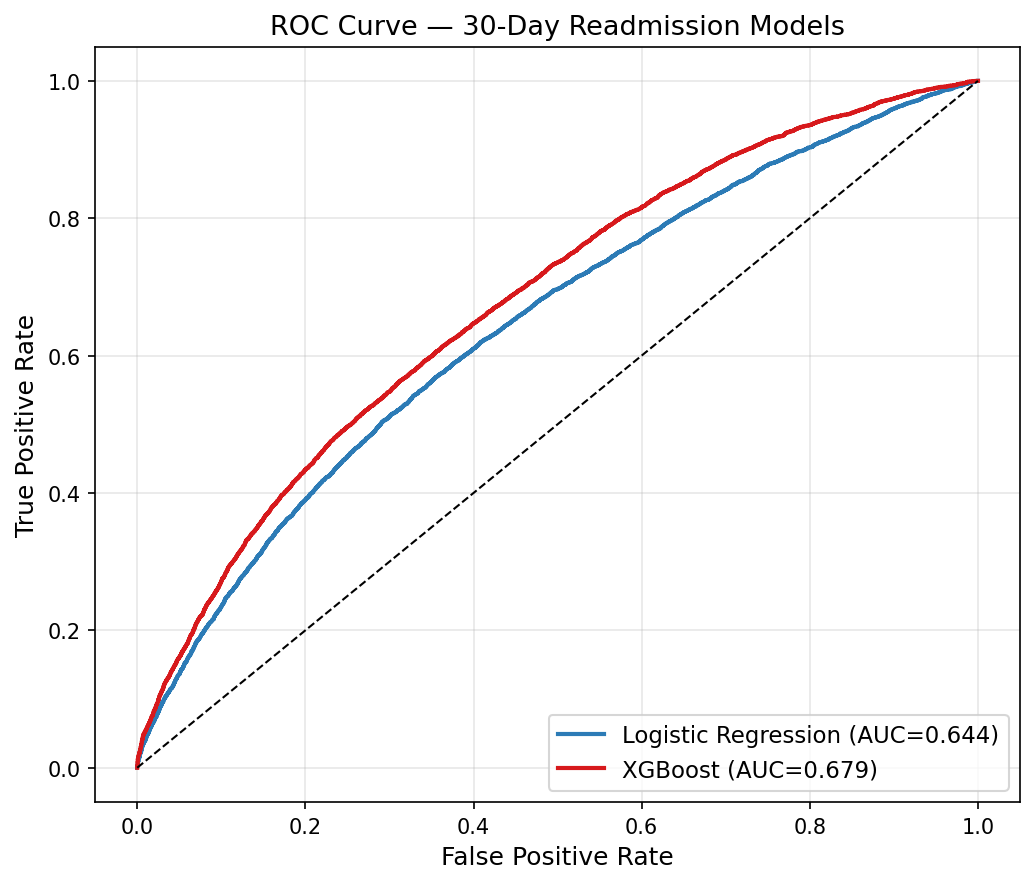

Saved to figures/roc_comparison.png


In [10]:
Path("figures").mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6))

for model, name, color in [
    (lr, f'Logistic Regression (AUC={lr_auc:.3f})', '#2C7BB6'),
    (xgb_model, f'XGBoost (AUC={xgb_auc:.3f})', '#D7191C')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, label=name, linewidth=2, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — 30-Day Readmission Models', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_comparison.png', bbox_inches='tight')
plt.show()
print("Saved to figures/roc_comparison.png")

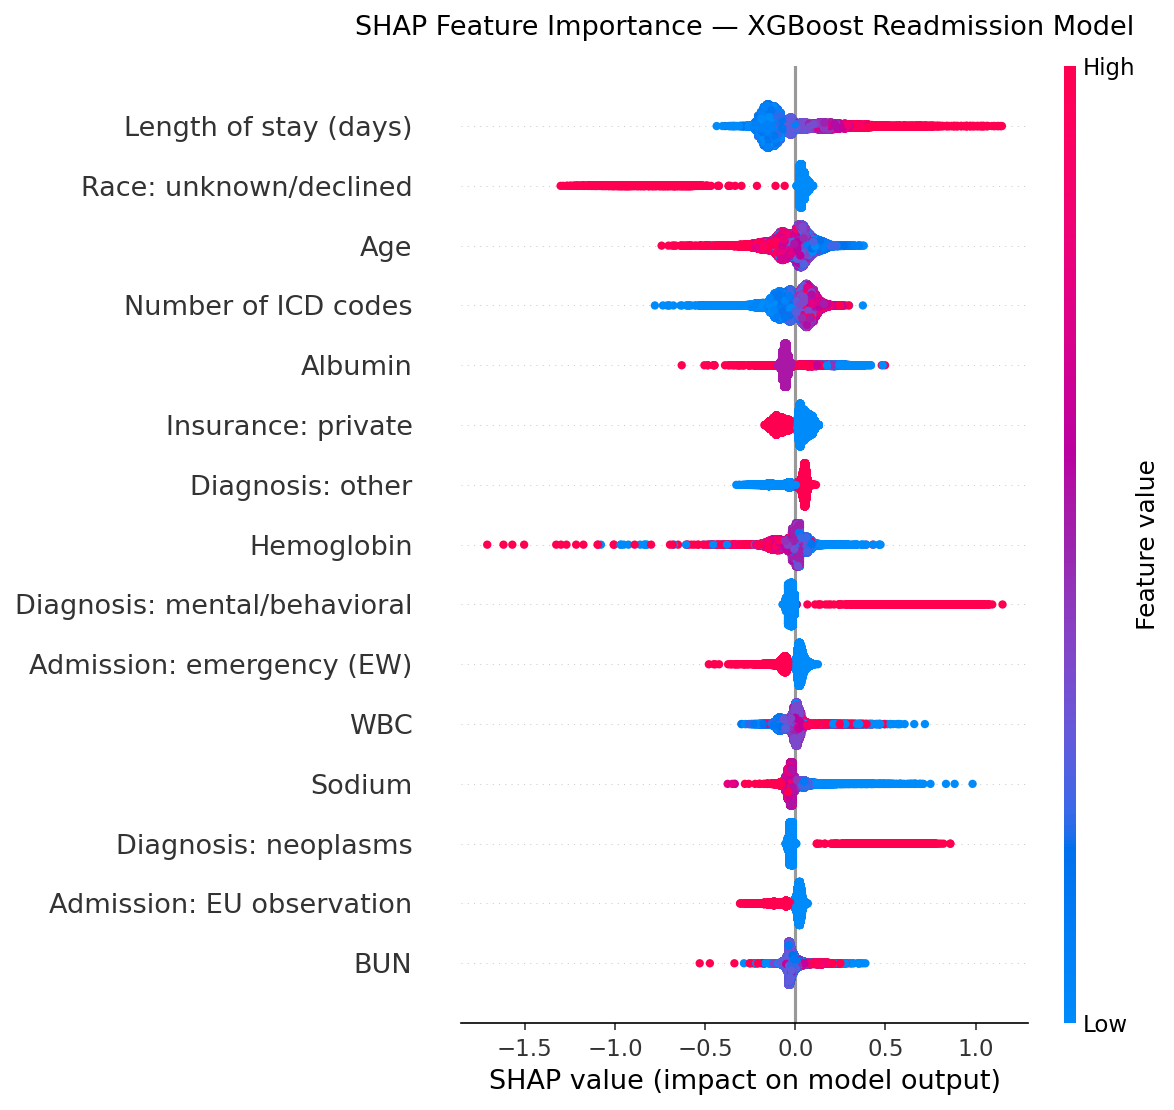

Saved clean SHAP plot


In [13]:
feature_name_map = {
    'los': 'Length of stay (days)',
    'anchor_age': 'Age',
    'n_icd_codes': 'Number of ICD codes',
    'prior_admits_6m': 'Prior admissions (6 months)',
    'creatinine': 'Creatinine',
    'bun': 'BUN',
    'hemoglobin': 'Hemoglobin',
    'wbc': 'WBC',
    'sodium': 'Sodium',
    'albumin': 'Albumin',
    'creatinine_high': 'Creatinine elevated (>1.5)',
    'hemoglobin_low': 'Hemoglobin low (<10)',
    'wbc_high': 'WBC elevated (>12)',
    'sodium_low': 'Sodium low (<135)',
    'race_collapsed_Unknown': 'Race: unknown/declined',
    'race_collapsed_White': 'Race: White',
    'race_collapsed_Hispanic': 'Race: Hispanic',
    'race_collapsed_Black': 'Race: Black',
    'insurance_Private': 'Insurance: private',
    'insurance_Medicare': 'Insurance: Medicare',
    'insurance_Other': 'Insurance: other',
    'admission_type_EW EMER.': 'Admission: emergency (EW)',
    'admission_type_EU OBSERVATION': 'Admission: EU observation',
    'admission_type_DIRECT EMER.': 'Admission: direct emergency',
    'admission_type_URGENT': 'Admission: urgent',
    'disease_category_Mental/Behavioral': 'Diagnosis: mental/behavioral',
    'disease_category_Neoplasms': 'Diagnosis: neoplasms',
    'disease_category_Digestive': 'Diagnosis: digestive',
    'disease_category_Other': 'Diagnosis: other',
    'high_risk_comorbidity': 'High-risk comorbidity flag',
}

X_test_named = X_test.rename(columns=feature_name_map)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_named,
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — XGBoost Readmission Model', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('figures/shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved clean SHAP plot")